In [1]:
## Non Variceal Coagulative Bleeding Prediction
# GBM  |  Random Forest  |  SVM  |  XGBoost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import RobustScaler
from sklearn.utils             import resample
from sklearn.ensemble          import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.metrics           import (
    roc_auc_score, accuracy_score, f1_score, precision_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier

In [4]:
df = pd.read_excel("/content/NVCB_anonymised_dataset.xlsx")

df = df.rename(columns={
    "PortalHypertension1_varice0_no_00"                               : "PortalHypertension",
    "@1_Alcohol2_2cry3_MET14_Viral5_autoimmunebiliary6_0thers7_78_alf": "Etiology",
    "CompensatedDecompensated"                                        : "PriorDecompensation",
})

print(f"Patients  : {len(df):,}")
print(f"NVCB = 1  : {(df['NVCB']==1).sum():,}  ({(df['NVCB']==1).mean()*100:.1f}%)")
print(f"NVCB = 0  : {(df['NVCB']==0).sum():,}  ({(df['NVCB']==0).mean()*100:.1f}%)")



FEATURES = [
    "EXTEMA10", "EXTEMCFT",  "EXTEMMCF",  "EXTEMMCFt",
    "EXTEMCT",  "EXTEMAUC",  "EXTEMACF",  "EXTEMMAXV",  "FIBTEMLI30",
    "FIBTEMA10","FIBTEMMCF", "FIBTEMAUC",
    "Hb",        "PLT",       "INR",       "Albumin",    "Creatinine",
    "Bilirubin", "Fibrinogen","TLC",       "Urea",
    "MELD",      "CTP",       "AKI",       "PriorDecompensation",
    "DIC",       "PortalHypertension", "Sepsis", "DM2",
]
FEATURES = [f for f in FEATURES if f in df.columns]

y = df["NVCB"].astype(int)
X = df[FEATURES].copy()

print(f"\nFeatures used : {len(FEATURES)}")


Patients  : 6,992
NVCB = 1  : 752  (10.8%)
NVCB = 0  : 6,240  (89.2%)

Features used : 29


In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"\nTrain : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")



Train : 4,194  |  Val : 1,399  |  Test : 1,399


In [6]:
df_tr          = X_train.copy()
df_tr["label"] = y_train.values
majority       = df_tr[df_tr["label"] == 0]
minority       = df_tr[df_tr["label"] == 1]

minority_up = resample(
    minority, replace=True,
    n_samples=int(len(majority) * 1.5),
    random_state=42
)

balanced    = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)
X_train_bal = balanced.drop(columns=["label"])
y_train_bal = balanced["label"]

print(f"\nBalanced train : {len(X_train_bal):,}  "
      f"(NVCB=1: {(y_train_bal==1).sum():,}  |  NVCB=0: {(y_train_bal==0).sum():,})")


scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


Balanced train : 9,357  (NVCB=1: 5,614  |  NVCB=0: 3,743)


In [7]:
print("\nTraining models …\n")

gbm_model = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, min_samples_leaf=10, subsample=0.8,
    random_state=42,
)
gbm_model.fit(X_train_sc, y_train_bal)
print("  1. GBM           done")

rf_model = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=2,
    class_weight="balanced", max_features="sqrt",
    n_jobs=-1, random_state=42,
)
rf_model.fit(X_train_sc, y_train_bal)
print("  2. Random Forest  done")

svm_model = SVC(
    C=2, kernel="rbf", gamma="scale",
    class_weight="balanced", probability=True, random_state=42,
)
svm_model.fit(X_train_sc, y_train_bal)
print("  3. SVM            done")

xgb_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    eval_metric="logloss", random_state=42, verbosity=0,
)
xgb_model.fit(X_train_sc, y_train_bal)
print("  4. XGBoost        done")



Training models …

  1. GBM           done
  2. Random Forest  done
  3. SVM            done
  4. XGBoost        done


In [8]:
MIN_SENSITIVITY = 0.80


def find_sensitivity_threshold(y_true, y_proba, min_sens=0.80):
    """
    Scan the ROC curve and return the threshold that gives
    sensitivity >= min_sens while maximising specificity.
    Falls back to the Youden-J point if no threshold meets the target.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    best_thresh   = None
    best_spec     = -1
    best_sens_val = 0

    for t, sens, fp_rate in zip(thresholds, tpr, fpr):
        spec = 1 - fp_rate
        if sens >= min_sens and spec > best_spec:
            best_thresh   = t
            best_spec     = spec
            best_sens_val = sens

    if best_thresh is None:
        # Fallback: Youden-J (maximise sens + spec)
        j_idx       = np.argmax(tpr - fpr)
        best_thresh = float(thresholds[j_idx])
        print(f"    [warning] could not reach sensitivity {min_sens:.0%} — "
              f"using Youden-J threshold {best_thresh:.3f}")

    return float(best_thresh)


# Get validation probabilities
gbm_val_proba = gbm_model.predict_proba(X_val_sc)[:, 1]
rf_val_proba  =  rf_model.predict_proba(X_val_sc)[:, 1]
svm_val_proba = svm_model.predict_proba(X_val_sc)[:, 1]
xgb_val_proba = xgb_model.predict_proba(X_val_sc)[:, 1]

# Find per-model thresholds on validation set
gbm_thr = find_sensitivity_threshold(y_val.values, gbm_val_proba, MIN_SENSITIVITY)
rf_thr  = find_sensitivity_threshold(y_val.values,  rf_val_proba, MIN_SENSITIVITY)
svm_thr = find_sensitivity_threshold(y_val.values, svm_val_proba, MIN_SENSITIVITY)
xgb_thr = find_sensitivity_threshold(y_val.values, xgb_val_proba, MIN_SENSITIVITY)

print(f"\nThresholds (tuned on validation set, target sensitivity ≥ {MIN_SENSITIVITY:.0%}):")
print(f"  GBM           : {gbm_thr:.3f}")
print(f"  Random Forest : {rf_thr:.3f}")
print(f"  SVM           : {svm_thr:.3f}")
print(f"  XGBoost       : {xgb_thr:.3f}")
print("  (each model has a different threshold — this is correct and expected)")



Thresholds (tuned on validation set, target sensitivity ≥ 80%):
  GBM           : 0.299
  Random Forest : 0.151
  SVM           : 0.383
  XGBoost       : 0.354
  (each model has a different threshold — this is correct and expected)


In [9]:
def evaluate(name, y_true, y_proba, threshold):
    y_pred         = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens           = tp / (tp + fn)
    spec           = tn / (tn + fp)
    return {
        "Model"      : name,
        "AUC"        : round(roc_auc_score(y_true, y_proba),    3),
        "Accuracy"   : round(accuracy_score(y_true, y_pred),    3),
        "Sensitivity": round(sens,                               3),
        "Specificity": round(spec,                               3),
        "Precision"  : round(precision_score(y_true, y_pred, zero_division=0), 3),
        "F1"         : round(f1_score(y_true, y_pred, zero_division=0),        3),
        "Avg Prec"   : round(average_precision_score(y_true, y_proba),         3),
        "Threshold"  : round(threshold, 3),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "_proba": y_proba,
        "_pred" : y_pred,
    }


# Test set probabilities (now we finally look at the test set)
gbm_test_proba = gbm_model.predict_proba(X_test_sc)[:, 1]
rf_test_proba  =  rf_model.predict_proba(X_test_sc)[:, 1]
svm_test_proba = svm_model.predict_proba(X_test_sc)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test_sc)[:, 1]

RESULTS = {
    "GBM"          : evaluate("GBM",           y_test.values, gbm_test_proba, gbm_thr),
    "Random Forest": evaluate("Random Forest",  y_test.values,  rf_test_proba,  rf_thr),
    "SVM"          : evaluate("SVM",            y_test.values, svm_test_proba, svm_thr),
    "XGBoost"      : evaluate("XGBoost",        y_test.values, xgb_test_proba, xgb_thr),
}

In [11]:
COLS = ["AUC", "Accuracy", "Sensitivity", "Specificity",
        "Precision", "F1", "Threshold"]

print("\n" + "=" * 106)
print(f"  {'Model':<16}" + "".join(f"{c:>11}" for c in COLS))
print("  " + "-" * 103)
for name, res in RESULTS.items():
    row = f"  {name:<16}"
    for c in COLS:
        v    = res[c]
        row += f"{str(round(v,3))+flag:>11}"
    print(row)
print("=" * 106)
print(f"  ✓ = sensitivity met target (≥ {MIN_SENSITIVITY:.0%})")

print(f"\nConfusion matrices (Test: {len(y_test):,} patients, "
      f"{y_test.sum()} bleeders):")
print(f"  {'Model':<16} {'TP':>5} {'FP':>6} {'FN':>6} {'TN':>6}")
print("  " + "-" * 38)
for name, res in RESULTS.items():
    print(f"  {name:<16} {res['TP']:>5} {res['FP']:>6} {res['FN']:>6} {res['TN']:>6}")


# 5-fold cross-validation AUC

print("\n5-fold cross-validation AUC (on balanced training data):\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in [
    ("GBM",           gbm_model),
    ("Random Forest",  rf_model),
    ("SVM",           svm_model),
    ("XGBoost",       xgb_model),
]:
    scores = cross_val_score(
        model, X_train_sc, y_train_bal,
        cv=cv, scoring="roc_auc", n_jobs=-1,
    )
    print(f"  {name:<16}  AUC = {scores.mean():.3f}  ±  {scores.std():.3f}")


  Model                   AUC   AccuracySensitivitySpecificity  Precision         F1  Threshold
  -------------------------------------------------------------------------------------------------------
  GBM                   0.854      0.727       0.84      0.713       0.26      0.397      0.299
  Random Forest         0.842      0.695        0.8      0.683      0.233       0.36      0.151
  SVM                    0.78       0.63      0.747      0.616      0.189      0.302      0.383
  XGBoost               0.855      0.743      0.793      0.737      0.266      0.399      0.354
  ✓ = sensitivity met target (≥ 80%)

Confusion matrices (Test: 1,399 patients, 150 bleeders):
  Model               TP     FP     FN     TN
  --------------------------------------
  GBM                126    358     24    891
  Random Forest      120    396     30    853
  SVM                112    480     38    769
  XGBoost            119    328     31    921

5-fold cross-validation AUC (on balanced train

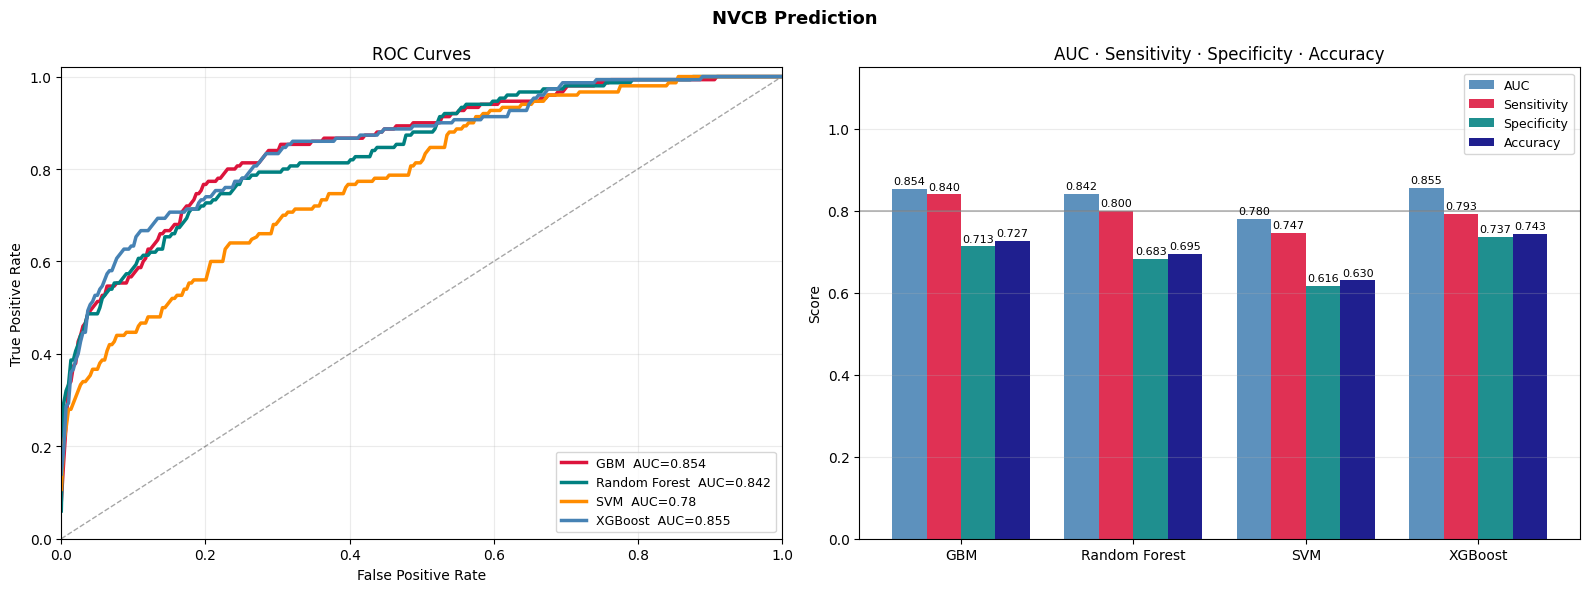

In [12]:
COLORS = {
    "GBM"          : "crimson",
    "Random Forest": "teal",
    "SVM"          : "darkorange",
    "XGBoost"      : "steelblue",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("NVCB Prediction", fontsize=13, fontweight="bold")

# ROC curves — smoothed by interpolating onto 300 evenly spaced FPR points
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.35)
for name, res in RESULTS.items():
    fpr, tpr, _ = roc_curve(y_test.values, res["_proba"])
    fpr_smooth  = np.linspace(0, 1, 300)
    tpr_smooth  = np.interp(fpr_smooth, fpr, tpr)
    ax.plot(fpr_smooth, tpr_smooth, color=COLORS[name], lw=2.5,
            label=f"{name}  AUC={res['AUC']}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Metric bar chart
ax = axes[1]
names  = list(RESULTS.keys())
met    = ["AUC", "Sensitivity", "Specificity", "Accuracy"]
colors = ["steelblue", "crimson", "teal", "navy"]
x = np.arange(len(names))
w = 0.20
for j, (m, c) in enumerate(zip(met, colors)):
    vals = [RESULTS[n][m] for n in names]
    bars = ax.bar(x + j * w, vals, w, label=m, color=c, alpha=0.88)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax.axhline(MIN_SENSITIVITY, color="gray", ls="-", lw=1.2, alpha=0.6)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim([0, 1.15])
ax.set_ylabel("Score")
ax.set_title("AUC · Sensitivity · Specificity · Accuracy")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("NVCB_roc_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

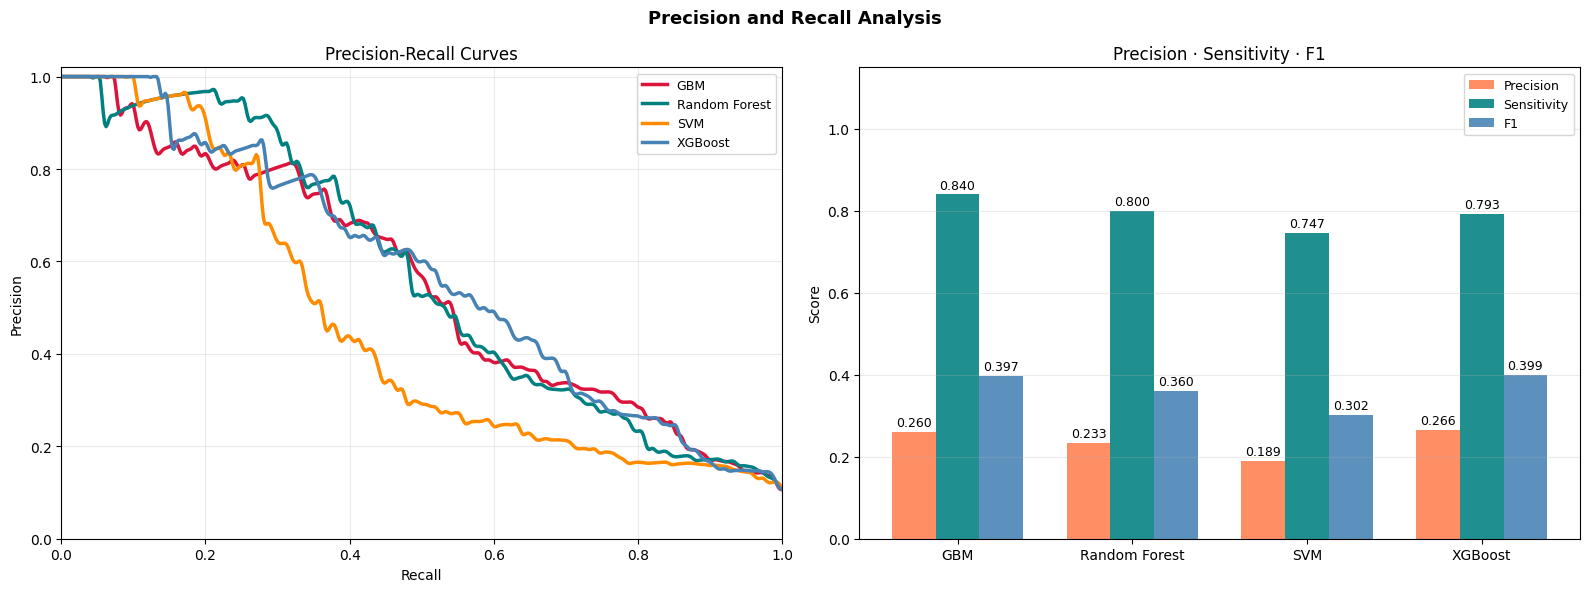

In [13]:
from scipy.interpolate import make_interp_spline

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Precision and Recall Analysis", fontsize=13, fontweight="bold")

# Precision-Recall Curves — smooth, no markers, no baseline
ax = axes[0]
for name, res in RESULTS.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test.values, res["_proba"])

    # smooth the curve using spline
    rec_unique, idx  = np.unique(rec_c, return_index=True)
    prec_unique      = prec_c[idx]
    spline           = make_interp_spline(rec_unique, prec_unique, k=3)
    rec_smooth       = np.linspace(0, 1, 500)
    prec_smooth      = np.clip(spline(rec_smooth), 0, 1)

    ax.plot(rec_smooth, prec_smooth, color=COLORS[name], lw=2.5,
            label=name)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Metric bar chart
ax = axes[1]
p_vals  = [RESULTS[n]["Precision"]   for n in names]
r_vals  = [RESULTS[n]["Sensitivity"] for n in names]
f1_vals = [RESULTS[n]["F1"]          for n in names]
x = np.arange(len(names))
w = 0.25
b1 = ax.bar(x - w, p_vals,  w, label="Precision",   color="coral",     alpha=0.88)
b2 = ax.bar(x,     r_vals,  w, label="Sensitivity", color="teal",      alpha=0.88)
b3 = ax.bar(x + w, f1_vals, w, label="F1",          color="steelblue", alpha=0.88)
ax.bar_label(b1, fmt="%.3f", fontsize=9, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=9, padding=2)
ax.bar_label(b3, fmt="%.3f", fontsize=9, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim([0, 1.15])
ax.set_ylabel("Score")
ax.set_title("Precision · Sensitivity · F1")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("NVCB_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

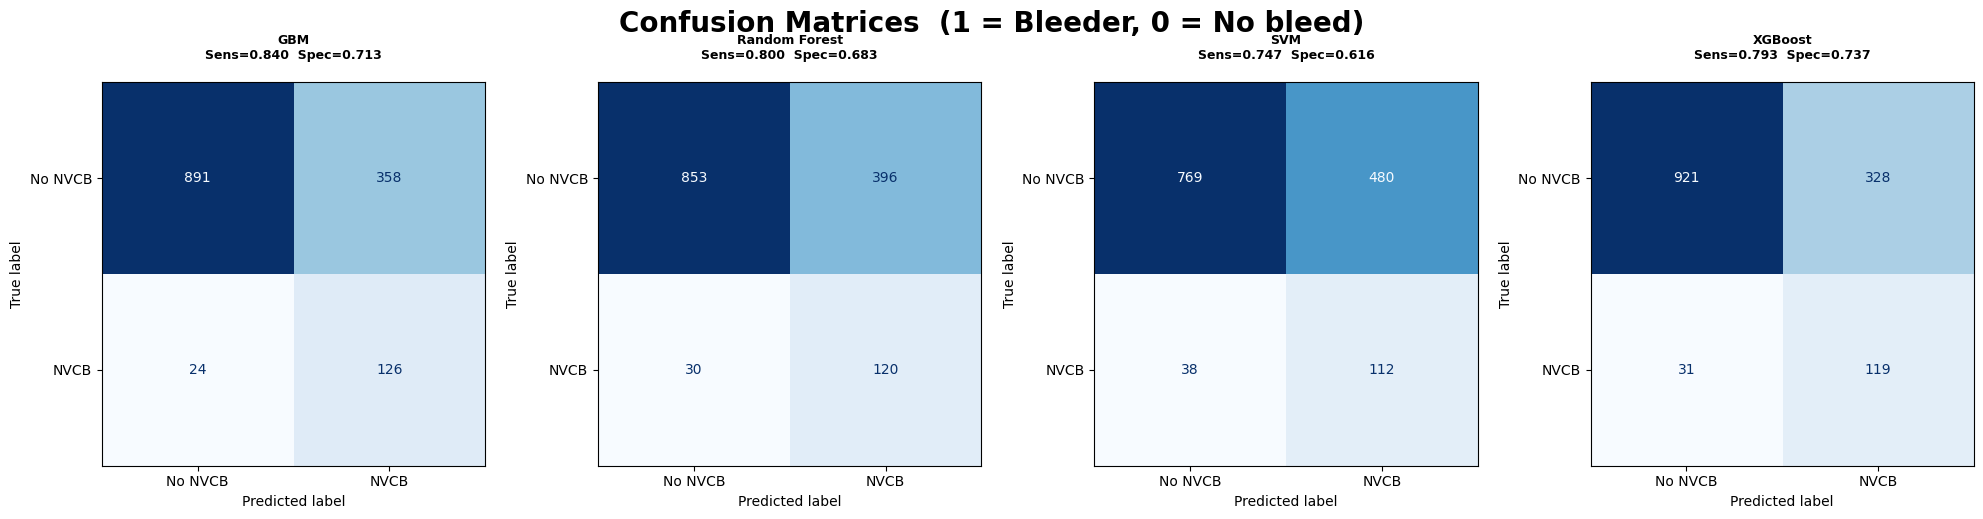

In [14]:
# Confusion matrices

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrices  (1 = Bleeder, 0 = No bleed)",
             fontsize=20, fontweight="bold")

for ax, (name, res) in zip(axes, RESULTS.items()):
    cm = confusion_matrix(y_test.values, res["_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No NVCB", "NVCB"]).plot(
        ax=ax, colorbar=False, cmap="Blues",
    )
    ax.set_title(
        f"{name}\n"
        f"Sens={res['Sensitivity']:.3f}  Spec={res['Specificity']:.3f}\n"
        ,
        fontsize=9, fontweight="bold",
    )

plt.tight_layout()
plt.savefig("NVCB_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

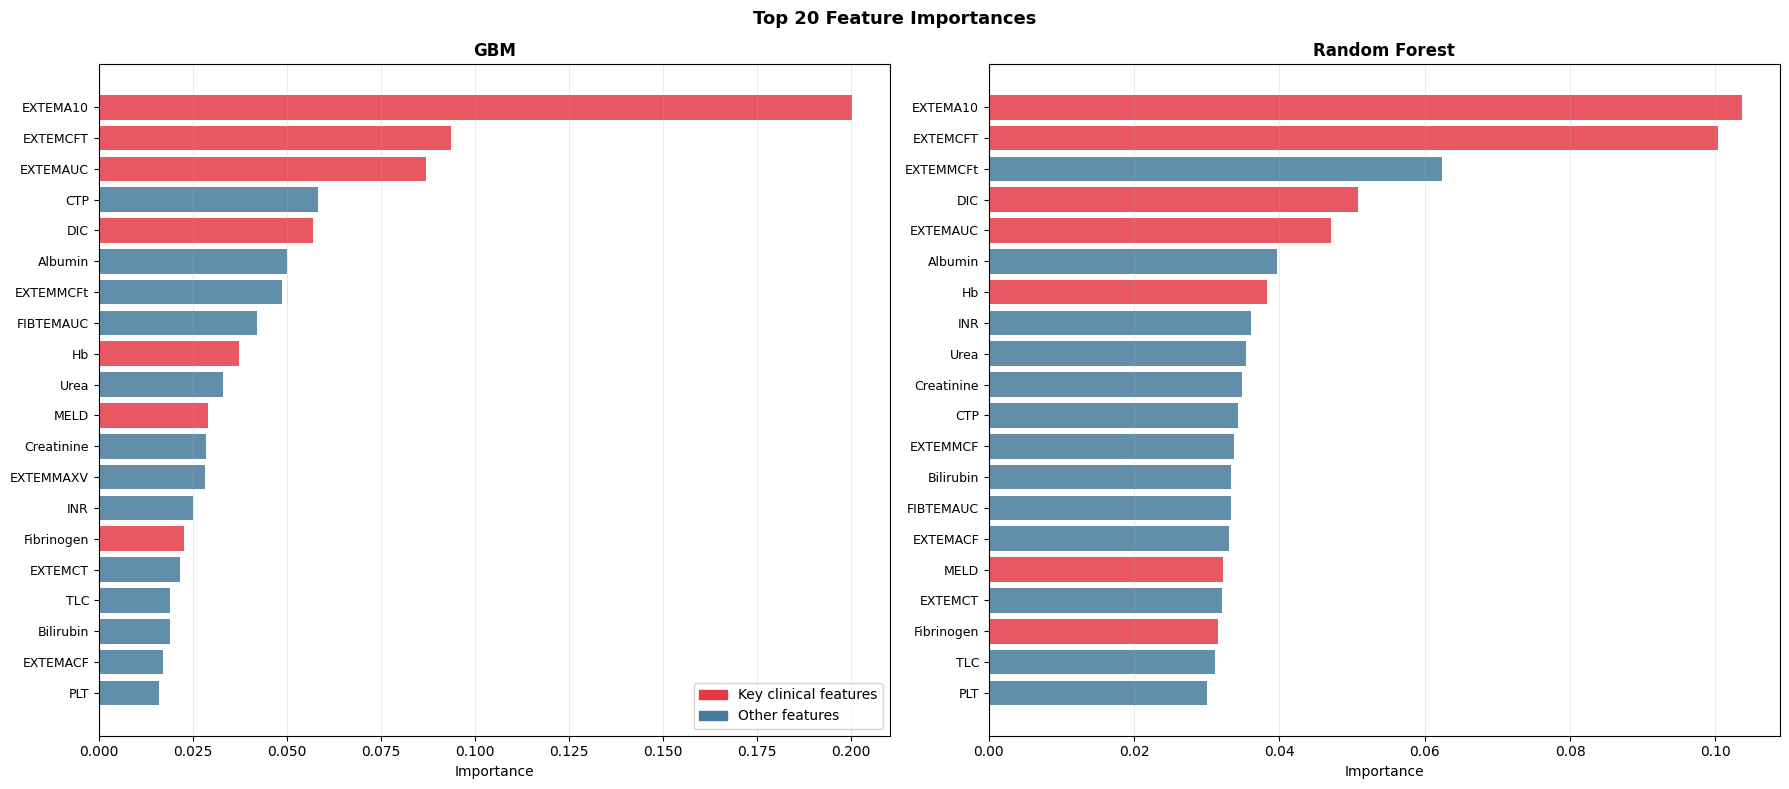


FINAL RESULTS:
        Model   AUC  Accuracy  Sensitivity  Specificity  Precision    F1  Threshold
          GBM 0.854     0.727        0.840        0.713      0.260 0.397      0.299
Random Forest 0.842     0.695        0.800        0.683      0.233 0.360      0.151
          SVM 0.780     0.630        0.747        0.616      0.189 0.302      0.383
      XGBoost 0.855     0.743        0.793        0.737      0.266 0.399      0.354


In [15]:
# Feature importance (GBM and Random Forest)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Top 20 Feature Importances", fontsize=13, fontweight="bold")

KEY = {"EXTEMA10", "EXTEMCFT", "DIC", "Hb", "AKI",
       "Fibrinogen", "FIBTEMA10", "MELD", "EXTEMAUC"}

for ax, (model, title) in zip(axes, [
    (gbm_model, "GBM"),
    (rf_model,  "Random Forest"),
]):
    fi     = pd.Series(model.feature_importances_, index=FEATURES) \
               .sort_values(ascending=False).head(20)
    colors = ["#e63946" if f in KEY else "#457b9d" for f in fi.index]
    ax.barh(range(len(fi)), fi.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi.index[::-1], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.25)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color="#e63946", label="Key clinical features"),
    Patch(color="#457b9d", label="Other features"),
], fontsize=10)

plt.tight_layout()
plt.savefig("NVCB_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


rows = [{
    "Model"      : res["Model"],
    "AUC"        : res["AUC"],
    "Accuracy"   : res["Accuracy"],
    "Sensitivity": res["Sensitivity"],
    "Specificity": res["Specificity"],
    "Precision"  : res["Precision"],
    "F1"         : res["F1"],
    "Avg Prec"   : res["Avg Prec"],
    "Threshold"  : res["Threshold"],
    "TP": res["TP"], "FP": res["FP"], "FN": res["FN"], "TN": res["TN"],
} for res in RESULTS.values()]

df_results = pd.DataFrame(rows)
df_results.to_excel("NVCB_results.xlsx", index=False)

print("\nFINAL RESULTS:")
print(df_results[["Model", "AUC", "Accuracy", "Sensitivity",
                   "Specificity", "Precision", "F1", "Threshold"]].to_string(index=False))


In [16]:
# Predict a single patient

PATIENT_SRNO = 2117   # change to any PatientID number

row = df[df["PatientID"] == f"PT{str(PATIENT_SRNO).zfill(5)}"]
if len(row) == 0:
    print(f"\nPatient PT{str(PATIENT_SRNO).zfill(5)} not found.")
else:
    r          = row.iloc[0]
    patient_sc = scaler.transform(r[FEATURES].values.reshape(1, -1))
    actual     = int(r["NVCB"])

    print("\n" + "=" * 64)
    print(f"  Patient : PT{str(PATIENT_SRNO).zfill(5)}")
    print(f"  Actual  : {'NVCB = 1  (BLEEDER)' if actual == 1 else 'NVCB = 0  (no bleed)'}")
    print("=" * 64)
    print(f"  {'Model':<16} {'Decision':>16}")
    print("  " + "-" * 58)
    for name, model, thr in [
        ("GBM",           gbm_model, gbm_thr),
        ("Random Forest",  rf_model,  rf_thr),
        ("SVM",           svm_model, svm_thr),
        ("XGBoost",       xgb_model, xgb_thr),
    ]:
        prob = model.predict_proba(patient_sc)[0, 1]
        dec  = "NVCB — bleeder" if prob >= thr else "No NVCB"
        tick = "correct" if (prob >= thr) == (actual == 1) else "wrong"
        print(f"  {name:<16}  {dec:>16}  ({tick})")
    print("=" * 64)



  Patient : PT02117
  Actual  : NVCB = 0  (no bleed)
  Model                    Decision
  ----------------------------------------------------------
  GBM                        No NVCB  (correct)
  Random Forest              No NVCB  (correct)
  SVM                        No NVCB  (correct)
  XGBoost                    No NVCB  (correct)


In [17]:
# Predict by entering patient values manually

patient_values = {
    "EXTEMA10"           : 45,
    "EXTEMCFT"           : 120,
    "EXTEMMCF"           : 8,
    "EXTEMMCFt"          : 7,
    "EXTEMCT"            : 80,
    "EXTEMAUC"           : 5000,
    "EXTEMACF"           : 30,
    "EXTEMMAXV"          : 10,
    "FIBTEMLI30"         : 5,
    "FIBTEMA10"          : 12,
    "FIBTEMMCF"          : 6,
    "FIBTEMAUC"          : 800,
    "Hb"                 : 7.5,
    "PLT"                : 60,
    "INR"                : 2.1,
    "Albumin"            : 2.4,
    "Creatinine"         : 1.8,
    "Bilirubin"          : 5.2,
    "Fibrinogen"         : 120,
    "TLC"                : 9.5,
    "Urea"               : 45,
    "MELD"               : 22,
    "CTP"                : 10,
    "AKI"                : 1,     # 1 = yes, 0 = no
    "PriorDecompensation": 1,     # 1 = decompensated, 0 = compensated
    "DIC"                : 0,     # 1 = yes, 0 = no
    "PortalHypertension" : 1,     # 1 = yes, 0 = no
    "Sepsis"             : 0,     # 1 = yes, 0 = no
    "DM2"                : 0,     # 1 = yes, 0 = no
}


patient_df = pd.DataFrame([patient_values])[FEATURES]
patient_sc = scaler.transform(patient_df)

print("=" * 48)
print("  NVCB RISK PREDICTION")
print("=" * 48)
print(f"  {'Model':<16}  {'Prediction':>20}")
print("  " + "-" * 44)

votes = []
for name, model, thr in [
    ("GBM",            gbm_model, gbm_thr),
    ("Random Forest",   rf_model,  rf_thr),
    ("SVM",            svm_model, svm_thr),
    ("XGBoost",        xgb_model, xgb_thr),
]:
    prob       = model.predict_proba(patient_sc)[0, 1]
    prediction = "NVCB — BLEEDER" if prob >= thr else "No NVCB"
    votes.append(1 if prob >= thr else 0)
    print(f"  {name:<16}  {prediction:>20}")

print("  " + "-" * 44)
print(f"  Models predicting NVCB : {sum(votes)} out of 4")

if sum(votes) >= 3:
    print("  FINAL VERDICT  :  NVCB LIKELY — consider intervention")
elif sum(votes) == 2:
    print("  FINAL VERDICT  :  BORDERLINE — review clinically")
else:
    print("  FINAL VERDICT  :  NVCB UNLIKELY — no bleed predicted")
print("=" * 48)

  NVCB RISK PREDICTION
  Model                       Prediction
  --------------------------------------------
  GBM                            No NVCB
  Random Forest                  No NVCB
  SVM                     NVCB — BLEEDER
  XGBoost                        No NVCB
  --------------------------------------------
  Models predicting NVCB : 1 out of 4
  FINAL VERDICT  :  NVCB UNLIKELY — no bleed predicted


In [21]:
# Install Streamlit
!pip install streamlit

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import streamlit as st
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import RobustScaler
from sklearn.utils           import resample
from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.metrics         import roc_curve


# Page config

st.set_page_config(
    page_title = "NVCB Prediction Tool",
    page_icon  = "🩺",
    layout     = "wide",
)

# Custom CSS

st.markdown("""
<style>
    .stApp { background-color: #f0f4f8; }
    h1 { color: #1a365d; font-family: Georgia, serif; }
    h3 { color: #2d3748; }

    .bleeder-box {
        background-color: #fff5f5;
        border-left: 6px solid #e53e3e;
        padding: 20px;
        border-radius: 8px;
        margin: 10px 0;
    }
    .nobleed-box {
        background-color: #f0fff4;
        border-left: 6px solid #38a169;
        padding: 20px;
        border-radius: 8px;
        margin: 10px 0;
    }
    .info-box {
        background-color: #ebf8ff;
        border-left: 4px solid #3182ce;
        padding: 12px 16px;
        border-radius: 6px;
        font-size: 0.9em;
        color: #2c5282;
    }
    .metric-box {
        background: white;
        padding: 16px;
        border-radius: 8px;
        text-align: center;
        box-shadow: 0 1px 3px rgba(0,0,0,0.1);
    }
</style>
""", unsafe_allow_html=True)


# All features needed for training

ALL_FEATURES = [
    "EXTEMA10", "EXTEMCFT", "EXTEMMCF", "EXTEMMCFt", "EXTEMCT",
    "EXTEMAUC", "EXTEMACF", "EXTEMMAXV", "FIBTEMLI30", "FIBTEMA10",
    "FIBTEMMCF", "FIBTEMAUC", "Hb", "PLT", "INR", "Albumin",
    "Creatinine", "Bilirubin", "Fibrinogen", "TLC", "Urea",
    "MELD", "CTP", "AKI", "PriorDecompensation",
    "DIC", "PortalHypertension", "Sepsis", "DM2",
]

# Top 10 features the user fills in (by combined GBM + RF importance)
TOP10 = [
    "EXTEMA10",   # ROTEM EXTEM amplitude at 10 min
    "EXTEMCFT",   # ROTEM EXTEM clot formation time
    "EXTEMAUC",   # ROTEM EXTEM area under curve
    "EXTEMMCFt",  # ROTEM EXTEM max clot firmness time
    "DIC",        # Disseminated intravascular coagulation
    "CTP",        # Child-Turcotte-Pugh score
    "Albumin",    # Serum albumin
    "Hb",         # Haemoglobin
    "FIBTEMAUC",  # ROTEM FIBTEM area under curve
    "Urea",       # Blood urea
]


# Train GBM

@st.cache_resource(show_spinner="Training GBM model on NVCB dataset — please wait ...")
def train_gbm(uploaded_file):

    df = pd.read_excel(uploaded_file)
    df = df.rename(columns={
        "PortalHypertension1_varice0_no_00"                               : "PortalHypertension",
        "@1_Alcohol2_2cry3_MET14_Viral5_autoimmunebiliary6_0thers7_78_alf": "Etiology",
        "CompensatedDecompensated"                                         : "PriorDecompensation",
    })

    feats = [f for f in ALL_FEATURES if f in df.columns]
    y     = df["NVCB"].astype(int)
    X     = df[feats]

    # 60 / 20 / 20 split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
    )

    # Oversample minority class on training set only
    df_tr       = X_train.copy(); df_tr["label"] = y_train.values
    majority    = df_tr[df_tr["label"] == 0]
    minority    = df_tr[df_tr["label"] == 1]
    minority_up = resample(
        minority, replace=True,
        n_samples=int(len(majority) * 1.5),
        random_state=42,
    )
    balanced    = pd.concat([majority, minority_up]).sample(frac=1, random_state=42)
    X_train_bal = balanced.drop(columns=["label"])
    y_train_bal = balanced["label"]

    # Scale
    scaler     = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train_bal)
    X_val_sc   = scaler.transform(X_val)

    # Train GBM
    gbm = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, min_samples_leaf=10, subsample=0.8,
        random_state=42,
    )
    gbm.fit(X_train_sc, y_train_bal)

    # Find threshold on validation set (sensitivity >= 80%)
    val_proba        = gbm.predict_proba(X_val_sc)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val.values, val_proba)
    best_thresh, best_spec = None, -1
    for t, sens, fp in zip(thresholds, tpr, fpr):
        if sens >= 0.80 and (1 - fp) > best_spec:
            best_thresh = t
            best_spec   = 1 - fp
    if best_thresh is None:
        best_thresh = float(thresholds[np.argmax(tpr - fpr)])

    return gbm, scaler, feats, float(best_thresh)


# Header

st.title("🩺 NVCB Prediction Tool")
st.markdown("**Non-Variceal Coagulopathic Bleeding in Acute Decompensated Cirrhosis**")
st.markdown("*Institute of Liver and Biliary Sciences (ILBS) · GBM Model · AUC 0.854 · Sensitivity 0.84*")
st.divider()


# Sidebar

with st.sidebar:
    st.header("⚙️ Setup")
    st.markdown("Upload the NVCB dataset to train the model.")
    uploaded = st.file_uploader("Upload NVCB_anonymised_dataset.xlsx", type=["xlsx"])
    st.divider()

    st.markdown("""
    **Model:** Gradient Boosting (GBM)

    **Why GBM?**
    - Highest AUC : 0.854
    - Sensitivity : 0.84
    - Best overall performer

    **Input:** Top 10 features by importance

    **Threshold:** Tuned on validation set to achieve sensitivity ≥ 80%
    """)

    st.divider()
    st.markdown("""
    <div class='info-box'>
    This tool is for clinical decision support only. All predictions must be
    reviewed by a qualified physician.
    </div>
    """, unsafe_allow_html=True)


# Wait for upload

if uploaded is None:
    st.info("👈 Please upload the NVCB dataset in the sidebar to train the model first.")
    st.stop() # Halts Streamlit execution and rendering
else:
    gbm, scaler, feats, threshold = train_gbm(uploaded)

    st.success(f"✅ GBM model trained successfully.  Threshold = {threshold:.3f}")
    st.divider()


    # Model performance summary

    st.subheader("📈 Model Performance (Test Set)")
    c1, c2, c3, c4 = st.columns(4)
    for col, label, value in zip(
        [c1, c2, c3, c4],
        ["AUC", "Sensitivity", "Specificity", "Accuracy"],
        ["0.854", "0.840", "0.713", "0.727"],
    ):
        with col:
            st.markdown(f"""
            <div class='metric-box'>
                <h2 style='margin:0; color:#1a365d'>{value}</h2>
                <p style='margin:0; color:#718096'>{label}</p>
            </div>
            """, unsafe_allow_html=True)

    st.divider()


    st.subheader("📋 Enter Patient Values")
    st.markdown("Fill in the **top 10 most important features** for prediction.")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**ROTEM Parameters**")
        EXTEMA10  = st.number_input("EXTEMA10  — EXTEM amplitude at 10 min (mm)",    min_value=0.0,   max_value=100.0,  value=45.0,  step=0.1)
        EXTEMCFT  = st.number_input("EXTEMCFT  — EXTEM clot formation time (sec)",   min_value=0.0,   max_value=1000.0, value=120.0, step=1.0)
        EXTEMAUC  = st.number_input("EXTEMAUC  — EXTEM area under curve",            min_value=0.0,   max_value=20000.0,value=5000.0,step=10.0)
        EXTEMMCFt = st.number_input("EXTEMMCFt — EXTEM max clot firmness time (min)",min_value=0.0,   max_value=100.0,  value=7.0,   step=0.1)
        FIBTEMAUC = st.number_input("FIBTEMAUC — FIBTEM area under curve",           min_value=0.0,   max_value=10000.0,value=800.0, step=10.0)

    with col2:
        st.markdown("**Clinical Parameters**")
        DIC     = st.selectbox("DIC — Disseminated intravascular coagulation", options=[0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
        CTP     = st.number_input("CTP — Child-Turcotte-Pugh score",          min_value=5,    max_value=15,     value=10,    step=1)
        Albumin = st.number_input("Albumin — Serum albumin (g/dL)",           min_value=0.0,  max_value=6.0,    value=2.4,   step=0.1)
        Hb      = st.number_input("Hb — Haemoglobin (g/dL)",                 min_value=0.0,  max_value=20.0,   value=7.5,   step=0.1)
        Urea    = st.number_input("Urea — Blood urea nitrogen (mg/dL)",       min_value=0.0,  max_value=300.0,  value=45.0,  step=1.0)

    st.divider()

    # ── Predict ───────────────────────────────────────────────────────────────────

    predict_clicked = st.button("🔍 Predict NVCB Risk", type="primary", use_container_width=True)

    if predict_clicked:

        # Build full feature vector — all non-top-10 features set to 0
        patient_dict = {f: 0.0 for f in feats}
        patient_dict.update({
            "EXTEMA10" : EXTEMA10,
            "EXTEMCFT" : EXTEMCFT,
            "EXTEMAUC" : EXTEMAUC,
            "EXTEMMCFt": EXTEMMCFt,
            "FIBTEMAUC": FIBTEMAUC,
            "DIC"      : float(DIC),
            "CTP"      : float(CTP),
            "Albumin"  : Albumin,
            "Hb"       : Hb,
            "Urea"     : Urea,
        })

        patient_df = pd.DataFrame([patient_dict])[feats]
        patient_sc = scaler.transform(patient_df)

        prob       = gbm.predict_proba(patient_sc)[0, 1]
        is_bleeder = prob >= threshold

        st.subheader("📊 GBM Prediction Result")

        if is_bleeder:
            st.markdown("""
            <div class='bleeder-box'>
                <h2 style='color:#e53e3e; margin:0'>🔴 NVCB LIKELY — Patient is a Bleeder</h2>
                <p style='margin:8px 0 0 0'>
                    The GBM model predicts this patient is at high risk of
                    Non-Variceal Coagulopathic Bleeding. Consider clinical intervention.
                </p>
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
            <div class='nobleed-box'>
                <h2 style='color:#38a169; margin:0'>🟢 NVCB UNLIKELY — No Bleed Predicted</h2>
                <p style='margin:8px 0 0 0'>
                    The GBM model predicts this patient is at low risk of
                    Non-Variceal Coagulopathic Bleeding.
                </p>
            </div>
            """, unsafe_allow_html=True)

        st.divider()

        # Values entered summary
        st.subheader("📌 Values Entered")
        summary = pd.DataFrame({
            "Feature"    : ["EXTEMA10",  "EXTEMCFT",  "EXTEMAUC",  "EXTEMMCFt", "FIBTEMAUC",
                            "DIC",       "CTP",        "Albumin",   "Hb",        "Urea"],
            "Value"      : [EXTEMA10,    EXTEMCFT,    EXTEMAUC,    EXTEMMCFt,   FIBTEMAUC,
                            DIC,         CTP,          Albumin,     Hb,          Urea],
            "Unit"       : ["mm",        "sec",        "AU",        "min",        "AU",
                            "0 = No / 1 = Yes", "score", "g/dL",  "g/dL",      "mg/dL"],
        })
        st.dataframe(summary, use_container_width=True, hide_index=True)



st.divider()
st.markdown("""
<small>
⚠️ <b>Disclaimer:</b> This tool is for research and clinical decision support only.
It does not replace clinical judgement. All predictions must be reviewed by a qualified physician.<br><br>
Developed at ILBS · GBM Model · AUC 0.854 · Sensitivity 0.84 · n = 6,992 patients
</small>
""", unsafe_allow_html=True)

2026-06-02 06:45:45.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.036 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.040 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 06:45:45.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()